# 🫀 Heart Disease Prediction
### K-Nearest Neighbors (K-NN) — Heart Disease Dataset

Importing libaries

In [56]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, ConfusionMatrixDisplay

Importing Dataset

In [57]:
dataset = pd.read_csv("heart.csv")
dataset.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


Feature Selection

In [58]:
correlation = dataset.corr()["target"].sort_values(ascending=False)
print(correlation)

features = ["cp", "thalach", "slope", "restecg", "fbs", "chol", "trestbps", "age", "sex", "thal", "ca", "exang", "oldpeak"]
target = "target"

x = dataset[features]
y = dataset[target]

target      1.000000
cp          0.434854
thalach     0.422895
slope       0.345512
restecg     0.134468
fbs        -0.041164
chol       -0.099966
trestbps   -0.138772
age        -0.229324
sex        -0.279501
thal       -0.337838
ca         -0.382085
exang      -0.438029
oldpeak    -0.438441
Name: target, dtype: float64


Spliting Dataset into Training set and Test set

In [59]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

Feature Scaling

In [60]:
scaler = StandardScaler()

x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

Finding Best K

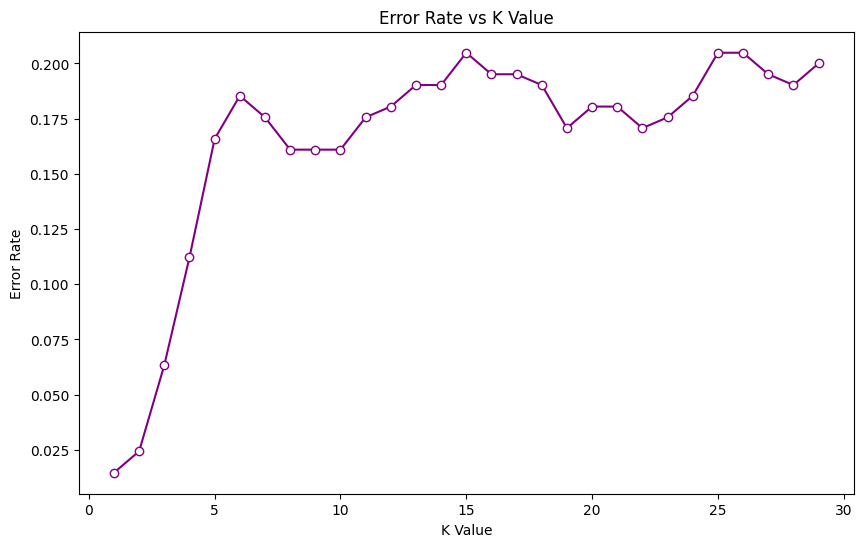

In [61]:
error_rates = []

for k in range(1, 30):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(x_train, y_train)
    preds = knn.predict(x_test)
    error_rates.append(1 - accuracy_score(y_test, preds))

plt.figure(figsize=(10, 6))
plt.plot(range(1, 30), error_rates, color="purple", marker="o", markerfacecolor="white")
plt.xlabel("K Value")
plt.ylabel("Error Rate")
plt.title("Error Rate vs K Value")
plt.show()

Training K-NN Model

In [62]:
model = KNeighborsClassifier(n_neighbors=3)
model.fit(x_train, y_train)

print("Model trained successfully! ✅")

Model trained successfully! ✅


Model Evaluation

In [63]:
y_pred = model.predict(x_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")
print(f"Precision: {precision_score(y_test, y_pred):.2f}")
print(f"Recall: {recall_score(y_test, y_pred):.2f}")

Accuracy: 0.94
Precision: 0.92
Recall: 0.95


Confusion Matrix

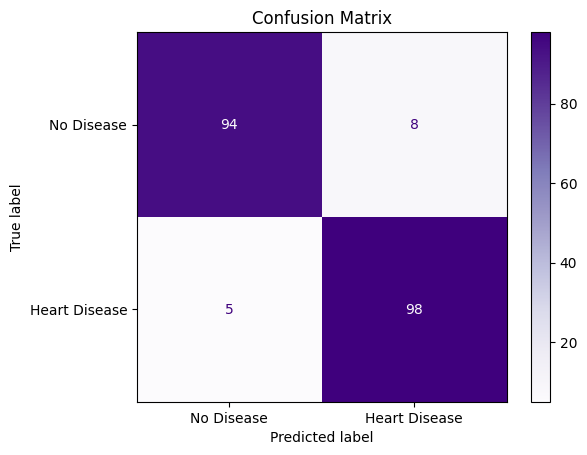

In [64]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Disease", "Heart Disease"])
disp.plot(cmap="Purples")
plt.title("Confusion Matrix")
plt.show()

K Value vs Error Rate

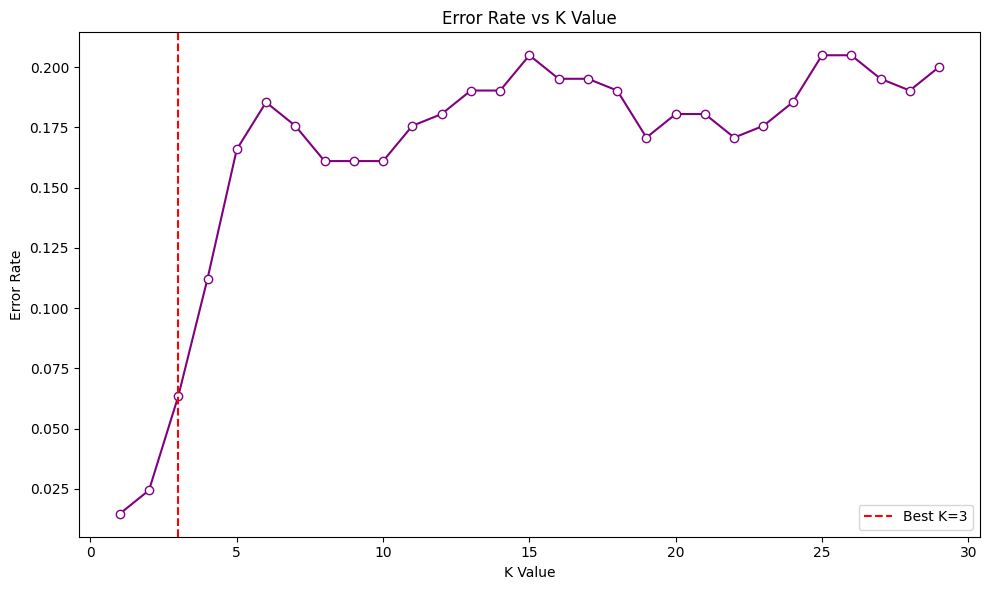

In [65]:
plt.figure(figsize=(10, 6))
plt.plot(range(1, 30), error_rates, color="purple", marker="o", markerfacecolor="white")
plt.axvline(x=3, color="red", linestyle="--", label="Best K=3")
plt.xlabel("K Value")
plt.ylabel("Error Rate")
plt.title("Error Rate vs K Value")
plt.legend()
plt.tight_layout()
plt.show()